# Task 4 — Advanced Fashion Visual Search

## Objective

Given a query fashion image, retrieve the Top-K visually similar fashion items from the supplied training collection.

Unlike Tasks 1–3, this task is formulated as an image-retrieval problem rather than predefined classification.

A convolutional embedding network is trained from scratch on the supplied Fashion dataset. Images are mapped to L2-normalised embedding vectors and ranked using cosine similarity.

The final system includes:

1. leakage-safe data partitioning;
2. a low-level pixel-similarity baseline;
3. batch-hard metric learning;
4. quantitative retrieval evaluation;
5. qualitative retrieval analysis;
6. a complete embedding index for deployment;
7. Top-K retrieval predictions for the unseen images.

Because the dataset does not provide human-labelled pairwise similarity judgements, `articleType` is used as the primary proxy relevance criterion for quantitative evaluation. Colour and gender are used only as secondary graded-relevance signals. This limitation is explicitly considered when interpreting results.

In [68]:
# ============================================
# CELL 1 - Setup, imports and project paths
# ============================================

from pathlib import Path
import json
import random
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    Sampler
)

from torchvision import transforms
from torchvision.transforms import InterpolationMode

from sklearn.model_selection import StratifiedGroupKFold


# ----------------------------
# Reproducibility
# ----------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)


# ----------------------------
# Device
# ----------------------------

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")

elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")

else:
    DEVICE = torch.device("cpu")


# ----------------------------
# Project root
# ----------------------------

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR

elif (CURRENT_DIR.parent / "A2_FashionDataset").exists():
    PROJECT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "Cannot locate A2_FashionDataset."
    )


DATA_ROOT = (
    PROJECT_DIR /
    "A2_FashionDataset"
)

DATASET_DIR = (
    DATA_ROOT /
    "FashionDataset"
)

PROCESSED_DIR = (
    DATA_ROOT /
    "processed"
)

TRAIN_IMAGE_DIR = (
    DATASET_DIR /
    "train" /
    "images_train"
)

TEST_IMAGE_DIR = (
    DATASET_DIR /
    "test" /
    "images_test"
)

CLEAN_TRAIN_CSV = (
    PROCESSED_DIR /
    "clean_train_metadata.csv"
)

PREDICTION_CSV = (
    PROCESSED_DIR /
    "prediction_metadata.csv"
)

HASH_CSV = (
    PROCESSED_DIR /
    "image_hashes.csv"
)


# ----------------------------
# Task 4 artifact folder
# ----------------------------

ARTIFACT_DIR = (
    PROJECT_DIR /
    "artifacts" /
    "task4tesr"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Project directory :", PROJECT_DIR)
print("PyTorch version   :", torch.__version__)
print("Machine           :", platform.machine())
print("MPS available     :", torch.backends.mps.is_available())
print("Device            :", DEVICE)
print("Artifact directory:", ARTIFACT_DIR)

Project directory : /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1
PyTorch version   : 2.13.0
Machine           : arm64
MPS available     : True
Device            : mps
Artifact directory: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task4tesr


## 1. Data Preparation and Leakage Control

The shared EDA identified repeated product names and exact duplicate image files. For visual retrieval, these duplicates present a particularly serious leakage risk because a near-identical image appearing in both gallery and evaluation sets could artificially inflate retrieval performance.

Therefore, the split group used in this task combines:

- identical `productDisplayName`;
- byte-identical image hashes.

Connected observations are forced into the same data partition.

In [69]:
# ============================================
# CELL 2 - Load processed metadata
# ============================================

train = pd.read_csv(
    CLEAN_TRAIN_CSV
)

prediction = pd.read_csv(
    PREDICTION_CSV
)


print(
    "Clean training observations:",
    len(train)
)

print(
    "Unseen test observations:",
    len(prediction)
)

print(
    "\nTraining columns:"
)

print(
    train.columns.tolist()
)


assert len(train) == 38612

assert len(prediction) == 5829

assert train["id"].is_unique
assert prediction["id"].is_unique

Clean training observations: 38612
Unseen test observations: 5829

Training columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']


In [70]:
# ============================================
# CELL 3 - Rebuild portable local image paths
# ============================================

train["image_path"] = train["id"].apply(
    lambda image_id:
    str(
        TRAIN_IMAGE_DIR /
        f"{image_id}.jpg"
    )
)

prediction["image_path"] = prediction["id"].apply(
    lambda image_id:
    str(
        TEST_IMAGE_DIR /
        f"{image_id}.jpg"
    )
)


train_path_valid = train[
    "image_path"
].apply(
    lambda path:
    Path(path).exists()
)

test_path_valid = prediction[
    "image_path"
].apply(
    lambda path:
    Path(path).exists()
)


print(
    "Valid training image paths:",
    train_path_valid.sum(),
    "/",
    len(train)
)

print(
    "Valid unseen image paths:",
    test_path_valid.sum(),
    "/",
    len(prediction)
)


assert train_path_valid.all()
assert test_path_valid.all()

Valid training image paths: 38612 / 38612
Valid unseen image paths: 5829 / 5829


In [71]:
# ============================================
# CELL 4 - Load exact-image hash information
# ============================================

if not HASH_CSV.exists():
    raise FileNotFoundError(
        "processed/image_hashes.csv is missing. "
        "Run the shared EDA notebook first."
    )


image_hashes = pd.read_csv(
    HASH_CSV,
    dtype={
        "id": str,
        "md5": str
    }
)


train["id_str"] = (
    train["id"]
    .astype(str)
)

image_hashes["id"] = (
    image_hashes["id"]
    .astype(str)
)


retrieval_df = train.merge(
    image_hashes[
        ["id", "md5"]
    ],
    left_on="id_str",
    right_on="id",
    how="left",
    suffixes=("", "_hash")
)


retrieval_df = (
    retrieval_df
    .drop(
        columns=["id_hash"]
    )
    .reset_index(drop=True)
)


print(
    "Retrieval observations:",
    len(retrieval_df)
)

print(
    "Missing hashes:",
    retrieval_df["md5"].isna().sum()
)


assert len(retrieval_df) == len(train)

assert retrieval_df[
    "md5"
].notna().all()


Retrieval observations: 38612
Missing hashes: 0


In [72]:
# ============================================
# CELL 5 - Build connected leakage groups
# ============================================

n = len(retrieval_df)

parent = np.arange(n)
rank = np.zeros(
    n,
    dtype=np.int16
)


def find_root(x):

    while parent[x] != x:

        parent[x] = parent[
            parent[x]
        ]

        x = parent[x]

    return x


def union(a, b):

    root_a = find_root(a)
    root_b = find_root(b)

    if root_a == root_b:
        return

    if rank[root_a] < rank[root_b]:

        parent[root_a] = root_b

    elif rank[root_a] > rank[root_b]:

        parent[root_b] = root_a

    else:

        parent[root_b] = root_a
        rank[root_a] += 1


# ----------------------------
# Union identical product names
# ----------------------------

first_for_name = {}

for index, value in enumerate(
    retrieval_df[
        "productDisplayName"
    ]
):

    if pd.isna(value):
        continue

    key = str(value)

    if key in first_for_name:

        union(
            index,
            first_for_name[key]
        )

    else:

        first_for_name[key] = index


# ----------------------------
# Union exact image duplicates
# ----------------------------

first_for_hash = {}

for index, value in enumerate(
    retrieval_df["md5"]
):

    if pd.isna(value):
        continue

    key = str(value)

    if key in first_for_hash:

        union(
            index,
            first_for_hash[key]
        )

    else:

        first_for_hash[key] = index


retrieval_df[
    "split_group"
] = [
    find_root(index)
    for index in range(n)
]


print(
    "Observations:",
    len(retrieval_df)
)

print(
    "Connected split groups:",
    retrieval_df[
        "split_group"
    ].nunique()
)

print(
    "Repeated product-name groups:",
    (
        retrieval_df[
            "productDisplayName"
        ]
        .value_counts()
        > 1
    ).sum()
)

print(
    "Repeated exact-image hashes:",
    (
        retrieval_df["md5"]
        .value_counts()
        > 1
    ).sum()
)

Observations: 38612
Connected split groups: 27337
Repeated product-name groups: 4447
Repeated exact-image hashes: 636


In [73]:
# ============================================
# CELL 6 - Task-specific label diagnostics
# ============================================

article_counts = (
    retrieval_df[
        "articleType"
    ]
    .value_counts()
)


diagnostics = pd.Series({

    "Observations":
        len(retrieval_df),

    "Article types":
        retrieval_df[
            "articleType"
        ].nunique(),

    "Minimum class size":
        int(
            article_counts.min()
        ),

    "Classes with 1 sample":
        int(
            (
                article_counts == 1
            ).sum()
        ),

    "Classes with <= 5 samples":
        int(
            (
                article_counts <= 5
            ).sum()
        ),

    "Classes with <= 10 samples":
        int(
            (
                article_counts <= 10
            ).sum()
        )
})


display(
    diagnostics.to_frame(
        "Value"
    )
)


assert retrieval_df[
    "articleType"
].isna().sum() == 0

,Value
Observations,38612
Article types,124
Minimum class size,1
Classes with 1 sample,6
Classes with <= 5 samples,23
Classes with <= 10 samples,32


## 2. Development / Validation / Final Evaluation Design

A three-way group-aware partition is used:

- **development set:** used to optimise the embedding network;
- **validation set:** used only for early stopping and learning-rate control;
- **final evaluation set:** untouched until the model configuration is locked.

Rare `articleType` labels are collapsed only for the purpose of stratification. Their original labels remain unchanged for model training and analysis.

In [74]:
# ============================================
# CELL 7 - Leakage-safe three-way split
# ============================================

split_df = retrieval_df.copy()


# Rare labels are collapsed ONLY
# for stratification stability.

counts = (
    split_df[
        "articleType"
    ]
    .value_counts()
)

rare_labels = counts[
    counts < 10
].index


split_df[
    "_stratify_label"
] = split_df[
    "articleType"
].where(
    ~split_df[
        "articleType"
    ].isin(
        rare_labels
    ),
    "__RARE__"
)


# ----------------------------
# Outer split:
# ~10% untouched final evaluation
# ----------------------------

outer_splitter = (
    StratifiedGroupKFold(
        n_splits=10,
        shuffle=True,
        random_state=SEED
    )
)


development_idx, final_idx = next(
    outer_splitter.split(
        split_df,
        y=split_df[
            "_stratify_label"
        ],
        groups=split_df[
            "split_group"
        ]
    )
)


development_pool = (
    split_df
    .iloc[
        development_idx
    ]
    .copy()
    .reset_index(drop=True)
)

final_pool = (
    split_df
    .iloc[
        final_idx
    ]
    .copy()
    .reset_index(drop=True)
)


# ----------------------------
# Inner split:
# ~10% validation overall
# ----------------------------

inner_splitter = (
    StratifiedGroupKFold(
        n_splits=9,
        shuffle=True,
        random_state=SEED + 1
    )
)


train_idx, val_idx = next(
    inner_splitter.split(
        development_pool,
        y=development_pool[
            "_stratify_label"
        ],
        groups=development_pool[
            "split_group"
        ]
    )
)


metric_train_df = (
    development_pool
    .iloc[
        train_idx
    ]
    .copy()
    .reset_index(drop=True)
)

metric_val_df = (
    development_pool
    .iloc[
        val_idx
    ]
    .copy()
    .reset_index(drop=True)
)


# Gallery for final evaluation:
# all non-final observations.

gallery_df = (
    pd.concat(
        [
            metric_train_df,
            metric_val_df
        ],
        ignore_index=True
    )
)


print(
    "Metric train     :",
    len(metric_train_df)
)

print(
    "Validation       :",
    len(metric_val_df)
)

print(
    "Final pool       :",
    len(final_pool)
)

print(
    "Evaluation gallery:",
    len(gallery_df)
)

print(
    "\nPercentages:"
)

print({

    "train":
        round(
            len(metric_train_df)
            /
            len(split_df)
            * 100,
            2
        ),

    "validation":
        round(
            len(metric_val_df)
            /
            len(split_df)
            * 100,
            2
        ),

    "final":
        round(
            len(final_pool)
            /
            len(split_df)
            * 100,
            2
        )
})

Metric train     : 30885
Validation       : 3862
Final pool       : 3865
Evaluation gallery: 34747

Percentages:
{'train': 79.99, 'validation': 10.0, 'final': 10.01}


In [75]:
# ============================================
# CELL 8 - Verify zero cross-split leakage
# ============================================

train_groups = set(
    metric_train_df[
        "split_group"
    ]
)

val_groups = set(
    metric_val_df[
        "split_group"
    ]
)

final_groups = set(
    final_pool[
        "split_group"
    ]
)


print(
    "Train / Validation group overlap:",
    len(
        train_groups
        &
        val_groups
    )
)

print(
    "Train / Final group overlap:",
    len(
        train_groups
        &
        final_groups
    )
)

print(
    "Validation / Final group overlap:",
    len(
        val_groups
        &
        final_groups
    )
)


assert not (
    train_groups
    &
    val_groups
)

assert not (
    train_groups
    &
    final_groups
)

assert not (
    val_groups
    &
    final_groups
)


# ----------------------------
# Explicit duplicate-hash checks
# ----------------------------

train_hashes = set(
    metric_train_df[
        "md5"
    ]
)

val_hashes = set(
    metric_val_df[
        "md5"
    ]
)

final_hashes = set(
    final_pool[
        "md5"
    ]
)


assert not (
    train_hashes
    &
    val_hashes
)

assert not (
    train_hashes
    &
    final_hashes
)

assert not (
    val_hashes
    &
    final_hashes
)


print(
    "\nExact-image leakage: 0"
)

print(
    "Combined leakage check PASSED."
)

Train / Validation group overlap: 0
Train / Final group overlap: 0
Validation / Final group overlap: 0

Exact-image leakage: 0
Combined leakage check PASSED.


In [76]:
# ============================================
# CELL 9 - Construct fixed final query set
# ============================================

MIN_GALLERY_RELEVANT = 5

MAX_QUERIES_PER_CLASS = 5


gallery_type_counts = (
    gallery_df[
        "articleType"
    ]
    .value_counts()
)


eligible_types = (
    gallery_type_counts[
        gallery_type_counts
        >=
        MIN_GALLERY_RELEVANT
    ]
    .index
)


eligible_final = (
    final_pool[
        final_pool[
            "articleType"
        ].isin(
            eligible_types
        )
    ]
    .copy()
)


# Class-balanced query sampling.
# Up to five queries per article type.

query_parts = []

for article_type, group in (
    eligible_final
    .groupby(
        "articleType",
        sort=True
    )
):

    n_samples = min(
        len(group),
        MAX_QUERIES_PER_CLASS
    )

    query_parts.append(
        group.sample(
            n=n_samples,
            random_state=SEED
        )
    )


EVAL_QUERY_DF = (
    pd.concat(
        query_parts,
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)


print(
    "Final pool observations:",
    len(final_pool)
)

print(
    "Eligible final observations:",
    len(eligible_final)
)

print(
    "Fixed evaluation queries:",
    len(EVAL_QUERY_DF)
)

print(
    "Evaluation article types:",
    EVAL_QUERY_DF[
        "articleType"
    ].nunique()
)

print(
    "Excluded final observations "
    "because gallery support <",
    MIN_GALLERY_RELEVANT,
    ":",
    len(final_pool)
    -
    len(eligible_final)
)


assert len(
    EVAL_QUERY_DF
) > 0


assert (
    EVAL_QUERY_DF[
        "articleType"
    ]
    .map(
        gallery_type_counts
    )
    >=
    MIN_GALLERY_RELEVANT
).all()

Final pool observations: 3865
Eligible final observations: 3859
Fixed evaluation queries: 353
Evaluation article types: 94
Excluded final observations because gallery support < 5 : 6


### Relevance Definition

The dataset contains no explicit human judgements indicating whether two images are visually similar. Consequently, quantitative retrieval evaluation requires a proxy definition.

Primary binary relevance:

- relevant = same `articleType`;
- non-relevant = different `articleType`.

For nDCG, graded relevance additionally rewards:

- matching `baseColour`;
- matching intended `gender`.

These metadata fields are used only for evaluation and metric-learning supervision. They are not provided to the embedding network as input features.

In [77]:
# ============================================
# CELL 10 - Image preprocessing
# ============================================

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 60

IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)


eval_transform = (
    transforms.Compose([

        transforms.Resize(
            IMAGE_SIZE,
            interpolation=
            InterpolationMode.BILINEAR
        ),

        transforms.ToTensor()
    ])
)


train_transform = (
    transforms.Compose([

        transforms.Resize(
            IMAGE_SIZE,
            interpolation=
            InterpolationMode.BILINEAR
        ),

        transforms.RandomHorizontalFlip(
            p=0.5
        ),

        transforms.RandomAffine(
            degrees=5,
            translate=(
                0.05,
                0.05
            ),
            scale=(
                0.92,
                1.08
            ),
            interpolation=
            InterpolationMode.BILINEAR
        ),

        transforms.ColorJitter(
            brightness=0.05,
            contrast=0.10,
            saturation=0.05
        ),

        transforms.ToTensor()
    ])
)


baseline_transform = (
    transforms.Compose([

        transforms.Resize(
            (32, 24),
            interpolation=
            InterpolationMode.BILINEAR
        ),

        transforms.ToTensor()
    ])
)


print(
    "CNN image size:",
    IMAGE_SIZE
)

print(
    "Pixel-baseline size:",
    (32, 24)
)

CNN image size: (80, 60)
Pixel-baseline size: (32, 24)


In [78]:
# ============================================
# CELL 11 - Image dataset
# ============================================

class FashionImageDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None,
        return_label=False
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

        self.return_label = (
            return_label
        )


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = (
            self.df
            .iloc[index]
        )

        with Image.open(
            row["image_path"]
        ) as image:

            image = (
                image
                .convert("RGB")
            )

            if self.transform:

                image = (
                    self.transform(
                        image
                    )
                )


        if self.return_label:

            return (
                image,
                row[
                    "articleType"
                ]
            )

        return (
            image,
            int(row["id"])
        )


sample_dataset = (
    FashionImageDataset(
        metric_train_df.head(2),
        transform=
        eval_transform
    )
)

sample_image, sample_id = (
    sample_dataset[0]
)


print(
    "Sample tensor shape:",
    sample_image.shape
)

print(
    "Pixel range:",
    float(sample_image.min()),
    "to",
    float(sample_image.max())
)

print(
    "Sample ID:",
    sample_id
)


assert tuple(
    sample_image.shape
) == (
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

Sample tensor shape: torch.Size([3, 80, 60])
Pixel range: 0.0117647061124444 to 1.0
Sample ID: 1163


In [79]:
# ============================================
# CELL 12 - Retrieval metrics
# ============================================

def binary_relevance(
    query_row,
    retrieved_rows
):

    return (
        retrieved_rows[
            "articleType"
        ].to_numpy()
        ==
        query_row[
            "articleType"
        ]
    ).astype(
        np.int8
    )


def graded_relevance(
    query_row,
    rows
):

    scores = np.zeros(
        len(rows),
        dtype=np.float32
    )


    # Main semantic relevance
    scores += (
        rows[
            "articleType"
        ].to_numpy()
        ==
        query_row[
            "articleType"
        ]
    ).astype(
        np.float32
    ) * 3.0


    # Secondary colour signal
    if pd.notna(
        query_row[
            "baseColour"
        ]
    ):

        scores += (
            rows[
                "baseColour"
            ].to_numpy()
            ==
            query_row[
                "baseColour"
            ]
        ).astype(
            np.float32
        ) * 1.0


    # Secondary target-user signal
    if pd.notna(
        query_row[
            "gender"
        ]
    ):

        scores += (
            rows[
                "gender"
            ].to_numpy()
            ==
            query_row[
                "gender"
            ]
        ).astype(
            np.float32
        ) * 0.5


    return scores


def precision_at_k(
    relevance,
    k
):

    return float(
        relevance[
            :k
        ].mean()
    )


def recall_at_k(
    relevance,
    total_relevant,
    k
):

    if total_relevant == 0:
        return np.nan

    return float(
        relevance[
            :k
        ].sum()
        /
        total_relevant
    )


def average_precision_at_k(
    relevance,
    total_relevant,
    k
):

    if total_relevant == 0:
        return np.nan

    hits = 0
    score = 0.0

    for rank, rel in enumerate(
        relevance[:k],
        start=1
    ):

        if rel:

            hits += 1

            score += (
                hits /
                rank
            )


    denominator = min(
        total_relevant,
        k
    )

    if denominator == 0:
        return 0.0

    return float(
        score /
        denominator
    )


def ndcg_at_k(
    retrieved_graded,
    ideal_graded,
    k
):

    retrieved_graded = (
        retrieved_graded[
            :k
        ]
    )

    ideal_graded = (
        ideal_graded[
            :k
        ]
    )


    discounts = np.log2(
        np.arange(
            2,
            len(
                retrieved_graded
            )
            + 2
        )
    )


    dcg = np.sum(
        (
            2 **
            retrieved_graded
            - 1
        )
        /
        discounts
    )


    idcg = np.sum(
        (
            2 **
            ideal_graded
            - 1
        )
        /
        discounts
    )


    if idcg == 0:
        return 0.0

    return float(
        dcg /
        idcg
    )

In [80]:
# ============================================
# CELL 13 - Memory-safe retrieval evaluator
# ============================================

def evaluate_retrieval(
    query_metadata,
    gallery_metadata,
    query_features,
    gallery_features,
    ks=(1, 5, 10),
    query_batch_size=64
):

    max_k = max(ks)

    assert (
        len(query_metadata)
        ==
        len(query_features)
    )

    assert (
        len(gallery_metadata)
        ==
        len(gallery_features)
    )


    gallery_features = (
        gallery_features
        .astype(
            np.float32
        )
    )

    query_features = (
        query_features
        .astype(
            np.float32
        )
    )


    gallery_type_counts = (
        gallery_metadata[
            "articleType"
        ]
        .value_counts()
    )


    rows = []


    for batch_start in range(
        0,
        len(query_metadata),
        query_batch_size
    ):

        batch_end = min(
            batch_start
            +
            query_batch_size,
            len(query_metadata)
        )


        batch_features = (
            query_features[
                batch_start:
                batch_end
            ]
        )


        similarity_matrix = (
            batch_features
            @
            gallery_features.T
        )


        for local_index in range(
            batch_end
            -
            batch_start
        ):

            global_index = (
                batch_start
                +
                local_index
            )

            query_row = (
                query_metadata
                .iloc[
                    global_index
                ]
            )


            scores = (
                similarity_matrix[
                    local_index
                ]
            )


            # Top-K only:
            # avoids sorting entire gallery.

            candidate_indices = (
                np.argpartition(
                    -scores,
                    max_k - 1
                )[
                    :max_k
                ]
            )


            candidate_indices = (
                candidate_indices[
                    np.argsort(
                        -scores[
                            candidate_indices
                        ]
                    )
                ]
            )


            retrieved = (
                gallery_metadata
                .iloc[
                    candidate_indices
                ]
            )


            binary = (
                binary_relevance(
                    query_row,
                    retrieved
                )
            )


            retrieved_graded = (
                graded_relevance(
                    query_row,
                    retrieved
                )
            )


            # Ideal nDCG ranking is
            # calculated from the entire gallery.

            all_graded = (
                graded_relevance(
                    query_row,
                    gallery_metadata
                )
            )


            ideal_graded = (
                np.sort(
                    all_graded
                )[::-1][
                    :max_k
                ]
            )


            total_relevant = int(
                gallery_type_counts.get(
                    query_row[
                        "articleType"
                    ],
                    0
                )
            )


            result = {

                "query_id":
                    int(
                        query_row[
                            "id"
                        ]
                    ),

                "articleType":
                    query_row[
                        "articleType"
                    ]
            }


            for k in ks:

                result[
                    f"P@{k}"
                ] = (
                    precision_at_k(
                        binary,
                        k
                    )
                )

                result[
                    f"R@{k}"
                ] = (
                    recall_at_k(
                        binary,
                        total_relevant,
                        k
                    )
                )

                result[
                    f"AP@{k}"
                ] = (
                    average_precision_at_k(
                        binary,
                        total_relevant,
                        k
                    )
                )

                result[
                    f"nDCG@{k}"
                ] = (
                    ndcg_at_k(
                        retrieved_graded,
                        ideal_graded,
                        k
                    )
                )


            rows.append(
                result
            )


    return pd.DataFrame(
        rows
    )

## 3. Retrieval Baseline

A learned representation should only be preferred if it improves retrieval over a simple non-learned alternative.

The baseline therefore:

1. resizes each image to a small fixed thumbnail;
2. flattens RGB pixel values;
3. L2-normalises the resulting vector;
4. ranks gallery images using cosine similarity.

Both the baseline and learned model are evaluated using exactly the same held-out queries and gallery.

In [81]:
# ============================================
# CELL 14 - Extract raw-pixel baseline features
# ============================================

def extract_pixel_features(
    dataframe,
    batch_size=256
):

    dataset = (
        FashionImageDataset(
            dataframe,
            transform=
            baseline_transform
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )


    feature_batches = []


    for images, _ in loader:

        features = (
            images
            .flatten(
                start_dim=1
            )
        )

        features = (
            F.normalize(
                features,
                p=2,
                dim=1
            )
        )

        feature_batches.append(
            features.numpy()
        )


    return np.concatenate(
        feature_batches,
        axis=0
    )


baseline_start = time.time()


baseline_gallery_features = (
    extract_pixel_features(
        gallery_df
    )
)

baseline_query_features = (
    extract_pixel_features(
        EVAL_QUERY_DF
    )
)


print(
    "Baseline gallery features:",
    baseline_gallery_features.shape
)

print(
    "Baseline query features:",
    baseline_query_features.shape
)

print(
    "Feature extraction seconds:",
    round(
        time.time()
        -
        baseline_start,
        2
    )
)

Baseline gallery features: (34747, 2304)
Baseline query features: (353, 2304)
Feature extraction seconds: 14.71


In [82]:
# ============================================
# CELL 15 - Evaluate pixel baseline
# ============================================

baseline_metrics = (
    evaluate_retrieval(
        EVAL_QUERY_DF,
        gallery_df,
        baseline_query_features,
        baseline_gallery_features,
        ks=(
            1,
            5,
            10
        )
    )
)


BASELINE_METRIC_COLUMNS = [
    "P@1",
    "P@5",
    "P@10",
    "R@5",
    "R@10",
    "AP@10",
    "nDCG@10"
]


baseline_summary = (
    baseline_metrics[
        BASELINE_METRIC_COLUMNS
    ]
    .mean()
)


print(
    "RAW PIXEL BASELINE"
)

display(
    baseline_summary
    .to_frame(
        "Score"
    )
    .round(4)
)

RAW PIXEL BASELINE


,Score
P@1,0.5779
P@5,0.4969
P@10,0.4501
R@5,0.0252
R@10,0.0389
AP@10,0.3939
nDCG@10,0.3466


In [83]:
# ============================================
# CELL 16 - Balanced P x K batch sampler
# ============================================

class PKBatchSampler(
    Sampler
):

    def __init__(
        self,
        labels,
        p_classes=32,
        k_samples=2,
        batches_per_epoch=None,
        seed=42,
        fixed=False
    ):

        self.labels = np.asarray(
            labels
        )

        self.p_classes = (
            p_classes
        )

        self.k_samples = (
            k_samples
        )

        self.seed = seed
        self.fixed = fixed
        self.epoch = 0


        self.label_to_indices = {}

        for label in np.unique(
            self.labels
        ):

            indices = np.where(
                self.labels
                ==
                label
            )[0]

            if len(indices) >= k_samples:

                self.label_to_indices[
                    label
                ] = indices


        self.valid_labels = np.array(
            list(
                self.label_to_indices
                .keys()
            ),
            dtype=object
        )


        if len(
            self.valid_labels
        ) < 2:

            raise ValueError(
                "Need at least two classes "
                "with sufficient samples."
            )


        self.p_classes = min(
            self.p_classes,
            len(
                self.valid_labels
            )
        )


        self.batch_size = (
            self.p_classes
            *
            self.k_samples
        )


        if batches_per_epoch is None:

            self.batches_per_epoch = max(
                1,
                len(self.labels)
                //
                self.batch_size
            )

        else:

            self.batches_per_epoch = int(
                batches_per_epoch
            )


    def set_epoch(
        self,
        epoch
    ):

        self.epoch = epoch


    def __len__(self):

        return (
            self.batches_per_epoch
        )


    def __iter__(self):

        effective_seed = (
            self.seed
            if self.fixed
            else
            self.seed
            +
            self.epoch
        )


        rng = np.random.default_rng(
            effective_seed
        )


        for _ in range(
            self.batches_per_epoch
        ):

            selected_labels = (
                rng.choice(
                    self.valid_labels,
                    size=
                    self.p_classes,
                    replace=False
                )
            )


            batch_indices = []


            for label in (
                selected_labels
            ):

                candidates = (
                    self.label_to_indices[
                        label
                    ]
                )


                selected = (
                    rng.choice(
                        candidates,
                        size=
                        self.k_samples,
                        replace=False
                    )
                )


                batch_indices.extend(
                    selected.tolist()
                )


            rng.shuffle(
                batch_indices
            )

            yield (
                batch_indices
            )

In [84]:
# ============================================
# CELL 17 - Metric-learning DataLoaders
# ============================================

P_CLASSES = 32
K_SAMPLES = 2


metric_train_dataset = (
    FashionImageDataset(
        metric_train_df,
        transform=
        train_transform,
        return_label=True
    )
)


metric_val_dataset = (
    FashionImageDataset(
        metric_val_df,
        transform=
        eval_transform,
        return_label=True
    )
)


train_sampler = PKBatchSampler(
    metric_train_df[
        "articleType"
    ].values,
    p_classes=P_CLASSES,
    k_samples=K_SAMPLES,
    seed=SEED,
    fixed=False
)


# Validation sampler is intentionally fixed.
# Every epoch evaluates the same batches.

val_sampler = PKBatchSampler(
    metric_val_df[
        "articleType"
    ].values,
    p_classes=min(
        P_CLASSES,
        metric_val_df[
            "articleType"
        ].nunique()
    ),
    k_samples=K_SAMPLES,
    batches_per_epoch=min(
        60,
        max(
            1,
            len(metric_val_df)
            //
            (
                P_CLASSES
                *
                K_SAMPLES
            )
        )
    ),
    seed=SEED + 100,
    fixed=True
)


train_loader = DataLoader(
    metric_train_dataset,
    batch_sampler=
    train_sampler,
    num_workers=0
)


val_loader = DataLoader(
    metric_val_dataset,
    batch_sampler=
    val_sampler,
    num_workers=0
)


print(
    "Trainable article types:",
    len(
        train_sampler
        .valid_labels
    )
)

print(
    "Validation article types:",
    len(
        val_sampler
        .valid_labels
    )
)

print(
    "Train batch size:",
    train_sampler.batch_size
)

print(
    "Train batches/epoch:",
    len(train_loader)
)

print(
    "Validation batches/epoch:",
    len(val_loader)
)

Trainable article types: 114
Validation article types: 82
Train batch size: 64
Train batches/epoch: 482
Validation batches/epoch: 60


In [85]:
# ============================================
# CELL 18 - CNN embedding network from scratch
# ============================================

class FashionEmbeddingCNN(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


        self.embedding_head = (
            nn.Sequential(

                nn.Flatten(),

                nn.Linear(
                    128,
                    256
                ),

                nn.ReLU(),

                nn.Dropout(
                    0.25
                ),

                nn.Linear(
                    256,
                    embedding_dim
                )
            )
        )


    def forward(
        self,
        x
    ):

        x = self.encoder(x)

        x = (
            self.embedding_head(
                x
            )
        )

        x = F.normalize(
            x,
            p=2,
            dim=1
        )

        return x


EMBEDDING_DIM = 128


embedding_model = (
    FashionEmbeddingCNN(
        embedding_dim=
        EMBEDDING_DIM
    )
    .to(DEVICE)
)


total_parameters = sum(
    parameter.numel()
    for parameter
    in embedding_model.parameters()
)


trainable_parameters = sum(
    parameter.numel()
    for parameter
    in embedding_model.parameters()
    if parameter.requires_grad
)


print(
    embedding_model
)

print(
    "\nTotal parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

print(
    "Device:",
    DEVICE
)

FashionEmbeddingCNN(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64

In [86]:
# ============================================
# CELL 19 - Batch-hard cosine triplet loss
# ============================================

def batch_hard_cosine_loss(
    embeddings,
    labels,
    margin=0.20
):

    # Embeddings are already L2-normalised.

    similarity = (
        embeddings
        @
        embeddings.T
    )


    distance = (
        1.0
        -
        similarity
    )


    labels = list(
        labels
    )


    label_ids = {
        label: index
        for index, label
        in enumerate(
            sorted(
                set(labels)
            )
        )
    }


    labels_tensor = torch.tensor(
        [
            label_ids[
                label
            ]
            for label
            in labels
        ],
        device=
        embeddings.device
    )


    same_class = (
        labels_tensor[
            :, None
        ]
        ==
        labels_tensor[
            None, :
        ]
    )


    identity = torch.eye(
        len(labels),
        dtype=torch.bool,
        device=
        embeddings.device
    )


    positive_mask = (
        same_class
        &
        ~identity
    )


    negative_mask = (
        ~same_class
    )


    hardest_positive = (
        distance
        .masked_fill(
            ~positive_mask,
            float("-inf")
        )
        .max(
            dim=1
        )
        .values
    )


    hardest_negative = (
        distance
        .masked_fill(
            ~negative_mask,
            float("inf")
        )
        .min(
            dim=1
        )
        .values
    )


    valid = (
        torch.isfinite(
            hardest_positive
        )
        &
        torch.isfinite(
            hardest_negative
        )
    )


    hardest_positive = (
        hardest_positive[
            valid
        ]
    )

    hardest_negative = (
        hardest_negative[
            valid
        ]
    )


    losses = F.relu(
        hardest_positive
        -
        hardest_negative
        +
        margin
    )


    loss = losses.mean()


    active_fraction = (
        (
            losses > 0
        )
        .float()
        .mean()
    )


    return (
        loss,
        hardest_positive.mean(),
        hardest_negative.mean(),
        active_fraction
    )

In [87]:
# ============================================
# CELL 20 - Training configuration
# ============================================

MARGIN = 0.20

MAX_EPOCHS = 20

EARLY_STOPPING_PATIENCE = 5


optimizer = torch.optim.Adam(
    embedding_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-6
    )
)


BEST_MODEL_PATH = (
    ARTIFACT_DIR /
    "task4_embedding_cnn.pt"
)


print(
    "Margin:",
    MARGIN
)

print(
    "Maximum epochs:",
    MAX_EPOCHS
)

print(
    "Early-stopping patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Best-model path:",
    BEST_MODEL_PATH
)

Margin: 0.2
Maximum epochs: 20
Early-stopping patience: 5
Best-model path: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task4tesr/task4_embedding_cnn.pt


In [88]:
# ============================================
# CELL 21 - Train batch-hard embedding CNN
# ============================================

history = {

    "train_loss": [],

    "val_loss": [],

    "train_positive_distance": [],

    "train_negative_distance": [],

    "val_positive_distance": [],

    "val_negative_distance": [],

    "active_triplet_fraction": [],

    "learning_rate": []
}


best_val_loss = float(
    "inf"
)

epochs_without_improvement = 0


training_start = time.time()


for epoch in range(
    MAX_EPOCHS
):

    # ========================================
    # TRAINING
    # ========================================

    train_sampler.set_epoch(
        epoch
    )

    embedding_model.train()


    train_loss_total = 0.0

    train_pos_total = 0.0

    train_neg_total = 0.0

    train_active_total = 0.0

    train_batches = 0


    for images, labels in (
        train_loader
    ):

        images = images.to(
            DEVICE
        )


        optimizer.zero_grad()


        embeddings = (
            embedding_model(
                images
            )
        )


        (
            loss,
            positive_distance,
            negative_distance,
            active_fraction

        ) = batch_hard_cosine_loss(

            embeddings,

            labels,

            margin=MARGIN
        )


        loss.backward()

        optimizer.step()


        train_loss_total += (
            loss.item()
        )

        train_pos_total += (
            positive_distance.item()
        )

        train_neg_total += (
            negative_distance.item()
        )

        train_active_total += (
            active_fraction.item()
        )

        train_batches += 1


    train_loss = (
        train_loss_total
        /
        train_batches
    )

    train_positive = (
        train_pos_total
        /
        train_batches
    )

    train_negative = (
        train_neg_total
        /
        train_batches
    )

    train_active = (
        train_active_total
        /
        train_batches
    )


    # ========================================
    # FIXED VALIDATION
    # ========================================

    embedding_model.eval()


    val_loss_total = 0.0

    val_pos_total = 0.0

    val_neg_total = 0.0

    val_batches = 0


    with torch.no_grad():

        for images, labels in (
            val_loader
        ):

            images = images.to(
                DEVICE
            )


            embeddings = (
                embedding_model(
                    images
                )
            )


            (
                val_batch_loss,
                val_positive_distance,
                val_negative_distance,
                _

            ) = batch_hard_cosine_loss(

                embeddings,

                labels,

                margin=MARGIN
            )


            val_loss_total += (
                val_batch_loss.item()
            )

            val_pos_total += (
                val_positive_distance.item()
            )

            val_neg_total += (
                val_negative_distance.item()
            )

            val_batches += 1


    val_loss = (
        val_loss_total
        /
        val_batches
    )

    val_positive = (
        val_pos_total
        /
        val_batches
    )

    val_negative = (
        val_neg_total
        /
        val_batches
    )


    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "train_positive_distance"
    ].append(
        train_positive
    )

    history[
        "train_negative_distance"
    ].append(
        train_negative
    )

    history[
        "val_positive_distance"
    ].append(
        val_positive
    )

    history[
        "val_negative_distance"
    ].append(
        val_negative
    )

    history[
        "active_triplet_fraction"
    ].append(
        train_active
    )

    history[
        "learning_rate"
    ].append(
        current_lr
    )


    improved = (
        val_loss
        <
        best_val_loss
        -
        1e-4
    )


    if improved:

        best_val_loss = (
            val_loss
        )

        epochs_without_improvement = 0


        torch.save(
            embedding_model
            .state_dict(),
            BEST_MODEL_PATH
        )


        status = (
            "BEST MODEL SAVED"
        )


    else:

        epochs_without_improvement += 1

        status = (
            "no improvement"
        )


    print(

        f"Epoch "
        f"{epoch + 1:02d}/"
        f"{MAX_EPOCHS} | "

        f"train_loss="
        f"{train_loss:.4f} | "

        f"val_loss="
        f"{val_loss:.4f} | "

        f"val_pos="
        f"{val_positive:.4f} | "

        f"val_neg="
        f"{val_negative:.4f} | "

        f"active="
        f"{train_active:.3f} | "

        f"lr="
        f"{current_lr:.6f} | "

        f"{status}"
    )


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


training_seconds = (
    time.time()
    -
    training_start
)


# Restore selected model

embedding_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

embedding_model.eval()


print(
    "\nTraining time:",
    round(
        training_seconds
        /
        60,
        2
    ),
    "minutes"
)

print(
    "Epochs completed:",
    len(
        history[
            "train_loss"
        ]
    )
)

print(
    "Best validation loss:",
    round(
        best_val_loss,
        4
    )
)

print(
    "Best model restored."
)

Epoch 01/20 | train_loss=0.2018 | val_loss=0.2000 | val_pos=0.0000 | val_neg=0.0000 | active=1.000 | lr=0.001000 | BEST MODEL SAVED
Epoch 02/20 | train_loss=0.2000 | val_loss=0.2000 | val_pos=0.0000 | val_neg=-0.0000 | active=1.000 | lr=0.001000 | no improvement
Epoch 03/20 | train_loss=0.2000 | val_loss=0.2000 | val_pos=0.0000 | val_neg=-0.0000 | active=1.000 | lr=0.001000 | no improvement
Epoch 04/20 | train_loss=0.2000 | val_loss=0.2000 | val_pos=0.0000 | val_neg=-0.0000 | active=1.000 | lr=0.000500 | no improvement
Epoch 05/20 | train_loss=0.2000 | val_loss=0.2000 | val_pos=0.0000 | val_neg=-0.0000 | active=1.000 | lr=0.000500 | no improvement
Epoch 06/20 | train_loss=0.2000 | val_loss=0.2000 | val_pos=0.0000 | val_neg=0.0000 | active=1.000 | lr=0.000500 | no improvement

Early stopping triggered.

Training time: 6.4 minutes
Epochs completed: 6
Best validation loss: 0.2
Best model restored.


,train_loss,val_loss,train_positive_distance,train_negative_distance,val_positive_distance,val_negative_distance,active_triplet_fraction,learning_rate
1,0.200021,0.200001,4.622921e-05,2.478830e-05,7.143555e-07,-6.460274e-08,1.0,0.0010
2,0.200001,0.200001,6.941367e-07,9.311294e-09,6.375213e-07,-6.016344e-08,1.0,0.0010
3,0.200000,0.200000,7.966479e-08,-2.886636e-07,3.244107e-08,-3.256214e-07,1.0,0.0005
4,0.200000,0.200000,9.393219e-08,-2.543689e-07,5.171945e-08,-2.793657e-07,1.0,0.0005
5,0.200000,0.200000,3.679690e-08,-2.888027e-07,1.788139e-07,1.788139e-07,1.0,0.0005


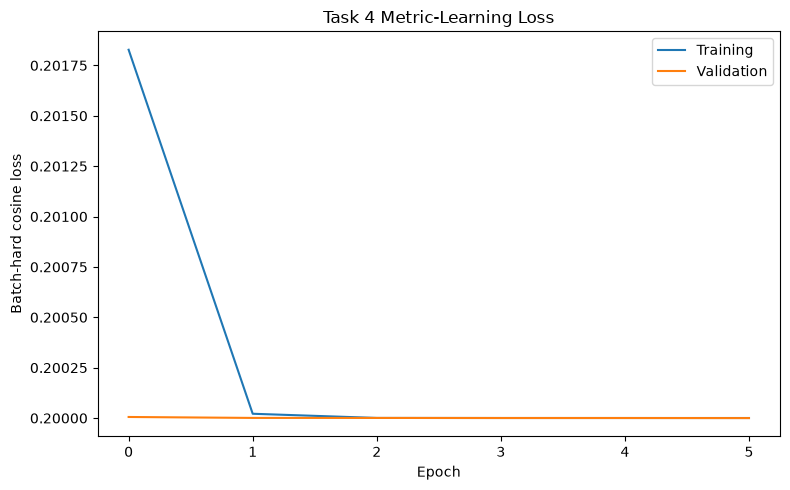

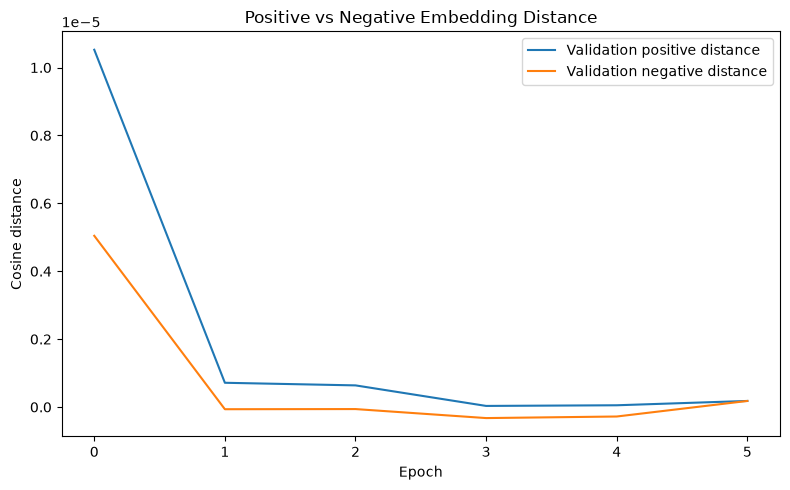

In [89]:
# ============================================
# CELL 22 - Training diagnostics
# ============================================

history_df = pd.DataFrame(
    history
)


display(
    history_df.tail()
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df[
        "train_loss"
    ],
    label="Training"
)

plt.plot(
    history_df[
        "val_loss"
    ],
    label="Validation"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Batch-hard cosine loss"
)

plt.title(
    "Task 4 Metric-Learning Loss"
)

plt.legend()

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df[
        "val_positive_distance"
    ],
    label=
    "Validation positive distance"
)

plt.plot(
    history_df[
        "val_negative_distance"
    ],
    label=
    "Validation negative distance"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cosine distance"
)

plt.title(
    "Positive vs Negative Embedding Distance"
)

plt.legend()

plt.tight_layout()

plt.show()

In [90]:
# ============================================
# CELL 23 - Embedding extraction
# ============================================

def extract_embeddings(
    model,
    dataframe,
    transform,
    batch_size=256
):

    dataset = (
        FashionImageDataset(
            dataframe,
            transform=
            transform
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=
        batch_size,
        shuffle=False,
        num_workers=0
    )


    embedding_batches = []

    id_batches = []


    model.eval()


    with torch.no_grad():

        for images, ids in (
            loader
        ):

            images = images.to(
                DEVICE
            )


            embeddings = (
                model(
                    images
                )
            )


            embedding_batches.append(
                embeddings
                .cpu()
                .numpy()
                .astype(
                    np.float32
                )
            )


            id_batches.append(
                ids.numpy()
            )


    return (

        np.concatenate(
            embedding_batches,
            axis=0
        ),

        np.concatenate(
            id_batches,
            axis=0
        )
    )

In [91]:
# ============================================
# CELL 24 - Final evaluation embeddings
# ============================================

evaluation_start = time.time()


gallery_embeddings, gallery_ids = (
    extract_embeddings(
        embedding_model,
        gallery_df,
        eval_transform
    )
)


query_embeddings, query_ids = (
    extract_embeddings(
        embedding_model,
        EVAL_QUERY_DF,
        eval_transform
    )
)


gallery_norms = np.linalg.norm(
    gallery_embeddings,
    axis=1
)


print(
    "Gallery embeddings:",
    gallery_embeddings.shape
)

print(
    "Query embeddings:",
    query_embeddings.shape
)

print(
    "Mean embedding norm:",
    round(
        float(
            gallery_norms.mean()
        ),
        6
    )
)

print(
    "Embedding extraction seconds:",
    round(
        time.time()
        -
        evaluation_start,
        2
    )
)


assert np.allclose(
    gallery_norms.mean(),
    1.0,
    atol=1e-3
)

Gallery embeddings: (34747, 128)
Query embeddings: (353, 128)
Mean embedding norm: 1.0
Embedding extraction seconds: 25.08


In [92]:
# ============================================
# CELL 25 - Final learned retrieval evaluation
# ============================================

final_metrics = (
    evaluate_retrieval(
        EVAL_QUERY_DF,
        gallery_df,
        query_embeddings,
        gallery_embeddings,
        ks=(
            1,
            5,
            10
        )
    )
)


FINAL_METRIC_COLUMNS = [
    "P@1",
    "P@5",
    "P@10",
    "R@5",
    "R@10",
    "AP@10",
    "nDCG@10"
]


final_summary = (
    final_metrics[
        FINAL_METRIC_COLUMNS
    ]
    .mean()
)


print(
    "=" * 55
)

print(
    "FINAL TASK 4 VISUAL SEARCH RESULTS"
)

print(
    "=" * 55
)


display(
    final_summary
    .to_frame(
        "Score"
    )
    .round(4)
)

FINAL TASK 4 VISUAL SEARCH RESULTS


,Score
P@1,0.4108
P@5,0.3541
P@10,0.3218
R@5,0.0161
R@10,0.0265
AP@10,0.2578
nDCG@10,0.2609


In [93]:
# ============================================
# CELL 26 - Baseline vs learned embedding
# ============================================

comparison = pd.DataFrame({

    "Metric":
        FINAL_METRIC_COLUMNS,

    "Raw Pixel Baseline":
        [
            baseline_metrics[
                metric
            ].mean()

            for metric
            in FINAL_METRIC_COLUMNS
        ],

    "Batch-Hard CNN":
        [
            final_metrics[
                metric
            ].mean()

            for metric
            in FINAL_METRIC_COLUMNS
        ]
})


comparison[
    "Absolute Improvement"
] = (
    comparison[
        "Batch-Hard CNN"
    ]
    -
    comparison[
        "Raw Pixel Baseline"
    ]
)


display(
    comparison.round(4)
)

,Metric,Raw Pixel Baseline,Batch-Hard CNN,Absolute Improvement
0,P@1,0.5779,0.4108,-0.1671
1,P@5,0.4969,0.3541,-0.1428
2,P@10,0.4501,0.3218,-0.1283
3,R@5,0.0252,0.0161,-0.0091
4,R@10,0.0389,0.0265,-0.0124
5,AP@10,0.3939,0.2578,-0.1361
6,nDCG@10,0.3466,0.2609,-0.0857


In [94]:
# ============================================
# CELL 27 - Retrieval performance by item type
# ============================================

type_performance = (
    final_metrics
    .groupby(
        "articleType"
    )[
        [
            "P@1",
            "P@5",
            "P@10",
            "AP@10",
            "nDCG@10"
        ]
    ]
    .mean()
)


type_query_counts = (
    EVAL_QUERY_DF[
        "articleType"
    ]
    .value_counts()
)


type_performance[
    "Queries"
] = (
    type_query_counts
)


type_performance[
    "Gallery Items"
] = (
    gallery_type_counts
)


type_performance = (
    type_performance
    .sort_values(
        "P@5",
        ascending=False
    )
)


print(
    "Best-performing item types:"
)

display(
    type_performance
    .head(15)
    .round(4)
)


print(
    "\nLowest-performing item types:"
)

display(
    type_performance
    .tail(15)
    .round(4)
)

Best-performing item types:


,P@1,P@5,P@10,AP@10,nDCG@10,Queries,Gallery Items
articleType,,,,,,,
Nail Polish,1.0,1.00,0.70,0.7000,0.8032,1,18
Suspenders,1.0,1.00,1.00,1.0000,0.8377,3,37
Ties,1.0,1.00,0.94,0.9346,0.6104,5,194
Lipstick,1.0,1.00,0.50,0.5000,0.5755,1,14
Accessory Gift Set,1.0,0.96,0.88,0.8612,0.5413,5,96
Watches,0.8,0.88,0.78,0.7452,0.4216,5,2027
Sunglasses,1.0,0.88,0.84,0.8400,0.5139,5,943
Bra,1.0,0.84,0.82,0.8024,0.6307,5,268
Tshirts,1.0,0.80,0.80,0.6883,0.7638,5,6102



Lowest-performing item types:


,P@1,P@5,P@10,AP@10,nDCG@10,Queries,Gallery Items
articleType,,,,,,,
Bangle,0.0,0.0,0.00,0.0000,0.0222,2,56
Water Bottle,0.0,0.0,0.00,0.0000,0.0339,1,10
Travel Accessory,0.0,0.0,0.00,0.0000,0.0842,1,12
Tights,0.0,0.0,0.00,0.0000,0.0386,1,8
Clothing Set,0.0,0.0,0.00,0.0000,0.0582,2,6
Salwar,0.0,0.0,0.00,0.0000,0.0484,3,29
Swimwear,0.0,0.0,0.00,0.0000,0.0290,1,16
Gloves,0.0,0.0,0.05,0.0083,0.0488,2,18
Jumpsuit,0.0,0.0,0.00,0.0000,0.0509,1,10


## 5. Qualitative Retrieval Analysis

Retrieval metrics provide reproducible quantitative evidence, but metadata-based proxy relevance cannot fully capture human visual similarity.

The following examples therefore inspect retrieved images directly. This is particularly important for cases where two visually similar products have different metadata labels or where the same `articleType` contains visually diverse products.

In [95]:
# ============================================
# CELL 28 - Top-K search function
# ============================================

def search_top_k(
    query_embedding,
    gallery_embeddings,
    gallery_metadata,
    k=5
):

    scores = (
        gallery_embeddings
        @
        query_embedding
    )


    candidate_indices = (
        np.argpartition(
            -scores,
            k - 1
        )[
            :k
        ]
    )


    top_indices = (
        candidate_indices[
            np.argsort(
                -scores[
                    candidate_indices
                ]
            )
        ]
    )


    results = (
        gallery_metadata
        .iloc[
            top_indices
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    results[
        "similarity"
    ] = (
        scores[
            top_indices
        ]
    )


    return results

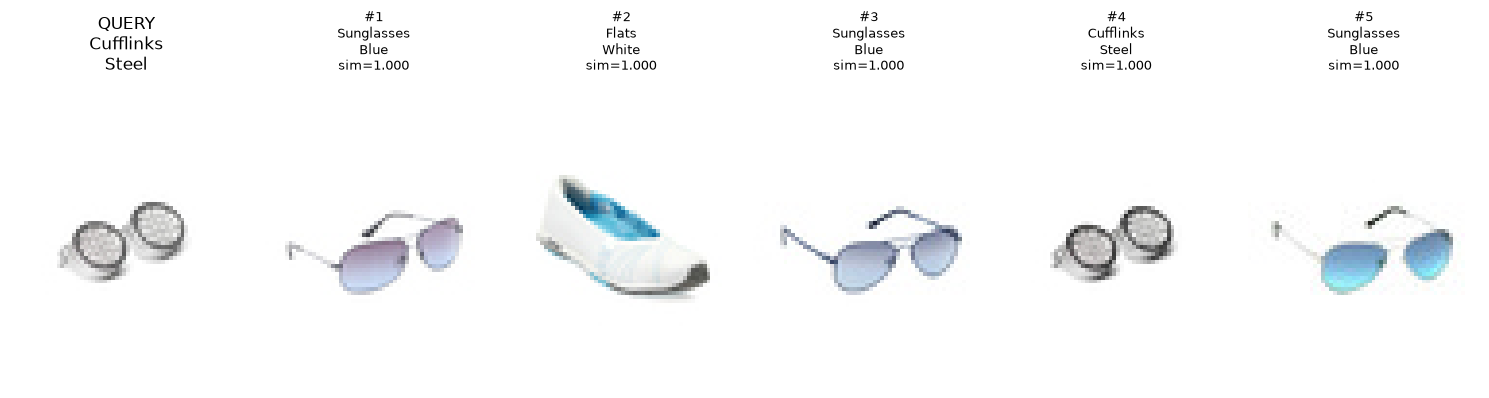

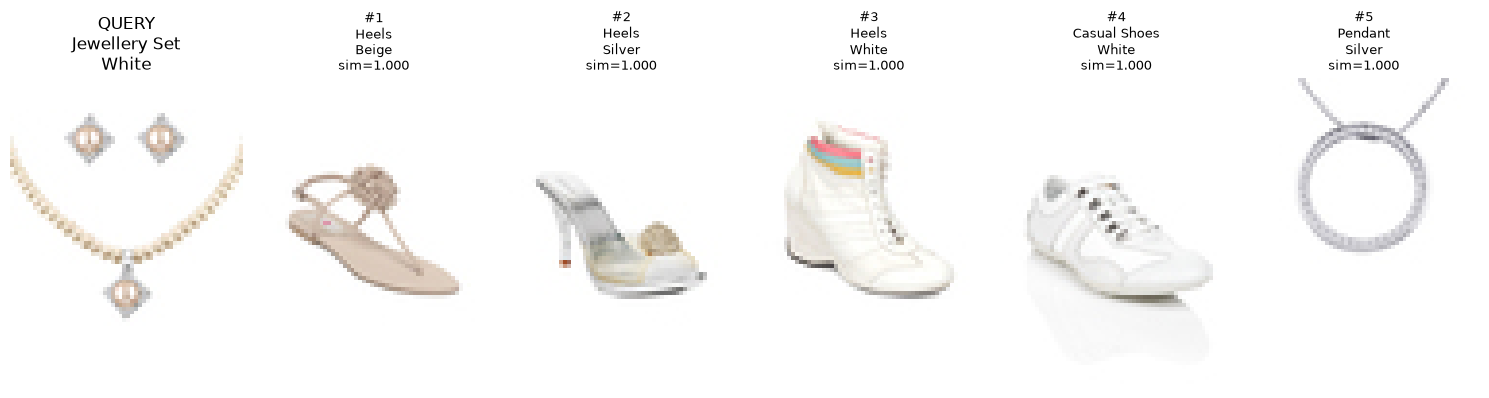

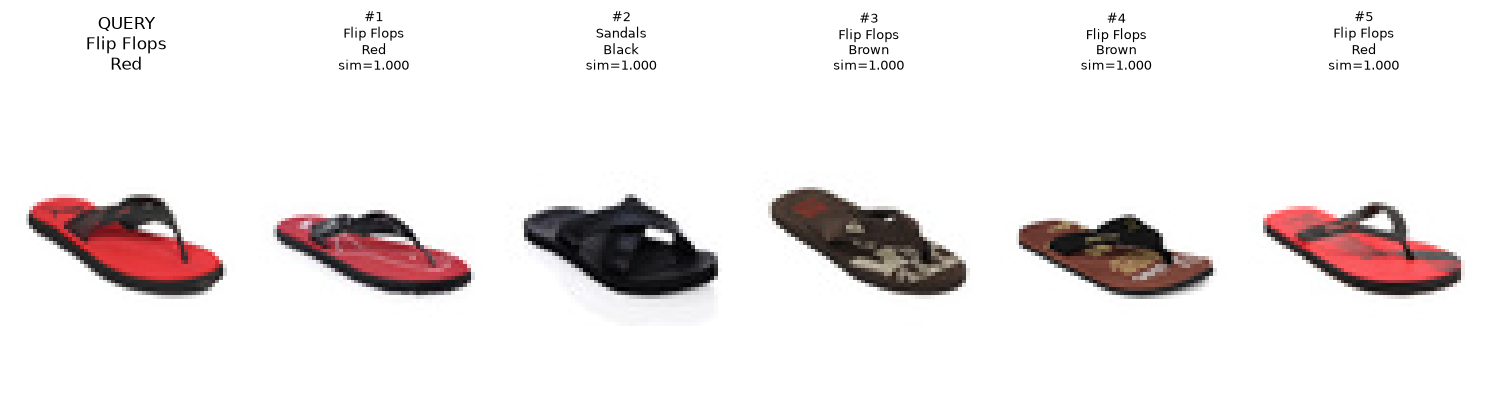

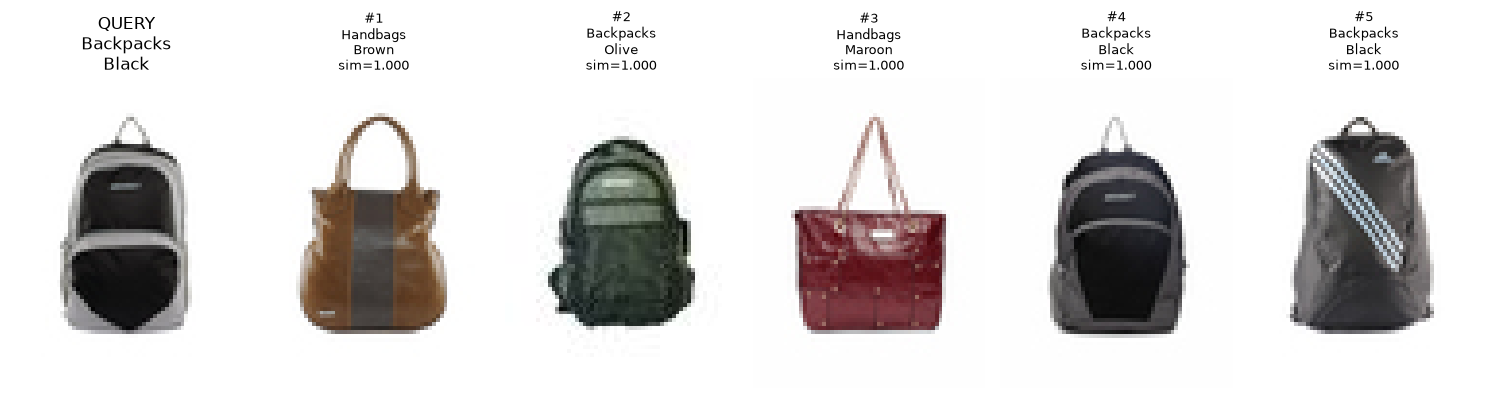

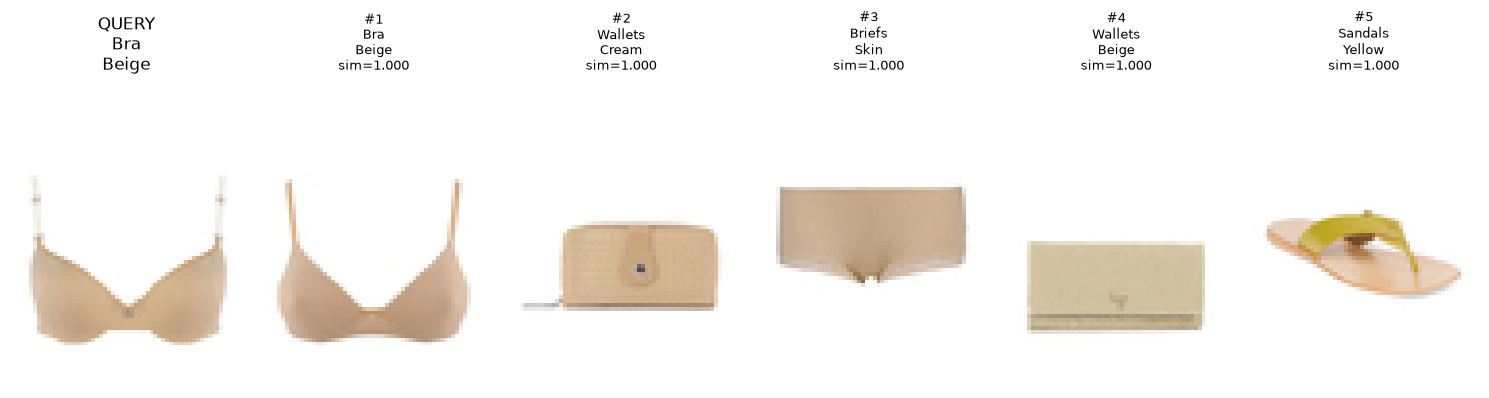

In [96]:
# ============================================
# CELL 29 - Representative Top-5 retrievals
# ============================================

NUM_EXAMPLES = 5
TOP_K = 5


rng = np.random.default_rng(
    SEED
)


example_indices = (
    rng.choice(
        len(
            EVAL_QUERY_DF
        ),
        size=min(
            NUM_EXAMPLES,
            len(
                EVAL_QUERY_DF
            )
        ),
        replace=False
    )
)


for query_index in (
    example_indices
):

    query_row = (
        EVAL_QUERY_DF
        .iloc[
            query_index
        ]
    )


    retrieved = (
        search_top_k(

            query_embeddings[
                query_index
            ],

            gallery_embeddings,

            gallery_df,

            k=TOP_K
        )
    )


    fig, axes = plt.subplots(

        1,

        TOP_K + 1,

        figsize=(15, 4)
    )


    query_image = (
        Image.open(
            query_row[
                "image_path"
            ]
        )
        .convert("RGB")
    )


    axes[0].imshow(
        query_image
    )

    axes[0].set_title(

        "QUERY\n"

        f"{query_row['articleType']}\n"

        f"{query_row['baseColour']}"
    )

    axes[0].axis(
        "off"
    )


    for rank in range(
        TOP_K
    ):

        row = (
            retrieved
            .iloc[
                rank
            ]
        )


        image = (
            Image.open(
                row[
                    "image_path"
                ]
            )
            .convert("RGB")
        )


        axes[
            rank + 1
        ].imshow(
            image
        )


        axes[
            rank + 1
        ].set_title(

            f"#{rank + 1}\n"

            f"{row['articleType']}\n"

            f"{row['baseColour']}\n"

            f"sim="
            f"{row['similarity']:.3f}",

            fontsize=9
        )


        axes[
            rank + 1
        ].axis(
            "off"
        )


    plt.tight_layout()

    plt.show()

In [97]:
# ============================================
# CELL 30 - Failure-pattern analysis
# ============================================

worst_queries = (
    final_metrics
    .sort_values(
        [
            "P@5",
            "nDCG@10"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(10)
)


display(
    worst_queries[
        [
            "query_id",
            "articleType",
            "P@1",
            "P@5",
            "P@10",
            "AP@10",
            "nDCG@10"
        ]
    ]
)


print(
    "\nMean P@5 of worst 10:",
    round(
        worst_queries[
            "P@5"
        ].mean(),
        4
    )
)

,query_id,articleType,P@1,P@5,P@10,AP@10,nDCG@10
130,1790,Backpacks,0.0,0.0,0.0,0.0,0.000000
269,13672,Jeans,0.0,0.0,0.0,0.0,0.000000
295,41527,Messenger Bag,0.0,0.0,0.0,0.0,0.000000
347,41854,Messenger Bag,0.0,0.0,0.0,0.0,0.000000
79,50671,Lounge Pants,0.0,0.0,0.0,0.0,0.002414
26,34898,Handbags,0.0,0.0,0.0,0.0,0.003220
64,44682,Dresses,0.0,0.0,0.0,0.0,0.004236
68,39524,Laptop Bag,0.0,0.0,0.0,0.0,0.004420
131,5586,Skirts,0.0,0.0,0.0,0.0,0.005295
250,38460,Mobile Pouch,0.0,0.0,0.0,0.0,0.005675



Mean P@5 of worst 10: 0.0


## 6. Deployment Index

After model selection and evaluation are complete, the selected embedding network is used to encode:

- all cleaned training images, creating the searchable product gallery;
- all unseen test images, creating query embeddings.

This stage does not modify the selected model or use unseen-test labels.

In [98]:
# ============================================
# CELL 31 - Build deployment embedding indexes
# ============================================

print(
    "Embedding full training gallery..."
)


full_train_embeddings, full_train_ids = (
    extract_embeddings(

        embedding_model,

        retrieval_df,

        eval_transform,

        batch_size=256
    )
)


print(
    "Embedding unseen test images..."
)


unseen_embeddings, unseen_ids = (
    extract_embeddings(

        embedding_model,

        prediction,

        eval_transform,

        batch_size=256
    )
)


print(
    "\nFull training index:",
    full_train_embeddings.shape
)

print(
    "Unseen query index:",
    unseen_embeddings.shape
)


assert (
    full_train_embeddings.shape
    ==
    (
        len(retrieval_df),
        EMBEDDING_DIM
    )
)

assert (
    unseen_embeddings.shape
    ==
    (
        5829,
        EMBEDDING_DIM
    )
)

Embedding full training gallery...
Embedding unseen test images...

Full training index: (38612, 128)
Unseen query index: (5829, 128)


In [99]:
# ============================================
# CELL 32 - Generate unseen Top-5 and save artifacts
# ============================================

UNSEEN_TOP_K = 5

retrieval_rows = []


for query_index in range(
    len(prediction)
):

    results = search_top_k(

        unseen_embeddings[
            query_index
        ],

        full_train_embeddings,

        retrieval_df,

        k=UNSEEN_TOP_K
    )


    query_id = int(
        prediction
        .iloc[
            query_index
        ][
            "id"
        ]
    )


    for rank, row in (
        results.iterrows()
    ):

        retrieval_rows.append({

            "query_id":
                query_id,

            "rank":
                rank + 1,

            "retrieved_id":
                int(
                    row[
                        "id"
                    ]
                ),

            "similarity":
                float(
                    row[
                        "similarity"
                    ]
                ),

            "retrieved_articleType":
                row[
                    "articleType"
                ],

            "retrieved_baseColour":
                row[
                    "baseColour"
                ]
        })


unseen_topk_df = (
    pd.DataFrame(
        retrieval_rows
    )
)


# ----------------------------
# Artifact paths
# ----------------------------

TRAIN_EMBEDDINGS_PATH = (
    ARTIFACT_DIR /
    "task4_train_embeddings.npy"
)

TRAIN_IDS_PATH = (
    ARTIFACT_DIR /
    "task4_train_ids.npy"
)

TEST_EMBEDDINGS_PATH = (
    ARTIFACT_DIR /
    "task4_test_embeddings.npy"
)

TEST_IDS_PATH = (
    ARTIFACT_DIR /
    "task4_test_ids.npy"
)

METADATA_PATH = (
    ARTIFACT_DIR /
    "task4_retrieval_metadata.csv"
)

TOPK_PATH = (
    ARTIFACT_DIR /
    "task4_test_top5.csv"
)

HISTORY_PATH = (
    ARTIFACT_DIR /
    "task4_training_history.csv"
)

EVALUATION_PATH = (
    ARTIFACT_DIR /
    "task4_evaluation_results.csv"
)

METRICS_PATH = (
    ARTIFACT_DIR /
    "task4_metrics.json"
)


# ----------------------------
# Save arrays and tables
# ----------------------------

np.save(
    TRAIN_EMBEDDINGS_PATH,
    full_train_embeddings
)

np.save(
    TRAIN_IDS_PATH,
    full_train_ids
)

np.save(
    TEST_EMBEDDINGS_PATH,
    unseen_embeddings
)

np.save(
    TEST_IDS_PATH,
    unseen_ids
)


retrieval_df.to_csv(
    METADATA_PATH,
    index=False
)


unseen_topk_df.to_csv(
    TOPK_PATH,
    index=False
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


final_metrics.to_csv(
    EVALUATION_PATH,
    index=False
)


# ----------------------------
# Metrics JSON
# ----------------------------

metrics_output = {

    "framework":
        "PyTorch",

    "device":
        str(DEVICE),

    "model":
        (
            "CNN embedding network "
            "trained from scratch with "
            "batch-hard cosine metric learning"
        ),

    "embedding_dim":
        EMBEDDING_DIM,

    "image_height":
        IMAGE_HEIGHT,

    "image_width":
        IMAGE_WIDTH,

    "margin":
        MARGIN,

    "p_classes":
        P_CLASSES,

    "k_samples":
        K_SAMPLES,

    "epochs_completed":
        len(
            history_df
        ),

    "training_minutes":
        float(
            training_seconds
            /
            60
        ),

    "best_validation_loss":
        float(
            best_val_loss
        ),

    "evaluation_queries":
        int(
            len(
                EVAL_QUERY_DF
            )
        ),

    "evaluation_gallery":
        int(
            len(
                gallery_df
            )
        ),

    "baseline":
        {
            metric:
                float(
                    baseline_metrics[
                        metric
                    ].mean()
                )

            for metric
            in FINAL_METRIC_COLUMNS
        },

    "final":
        {
            metric:
                float(
                    final_metrics[
                        metric
                    ].mean()
                )

            for metric
            in FINAL_METRIC_COLUMNS
        }
}


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metrics_output,
        file,
        indent=4
    )


print(
    "Unseen Top-5 rows:",
    len(
        unseen_topk_df
    )
)

print(
    "Unique unseen queries:",
    unseen_topk_df[
        "query_id"
    ].nunique()
)

display(
    unseen_topk_df.head(10)
)


assert (
    len(
        unseen_topk_df
    )
    ==
    5829
    *
    UNSEEN_TOP_K
)

assert (
    unseen_topk_df[
        "query_id"
    ].nunique()
    ==
    5829
)

Unseen Top-5 rows: 29145
Unique unseen queries: 5829


,query_id,rank,retrieved_id,similarity,retrieved_articleType,retrieved_baseColour
0,52003,1,45097,0.999986,Bra,Pink
1,52003,2,51981,0.999984,Lounge Tshirts,Black
2,52003,3,14302,0.999982,Tshirts,Brown
3,52003,4,14301,0.999982,Tshirts,Grey
4,52003,5,51976,0.999979,Lounge Pants,Pink
5,52007,1,33226,0.999999,Dresses,Navy Blue
6,52007,2,28746,0.999998,Kurtas,Magenta
7,52007,3,28744,0.999998,Kurtas,Blue
8,52007,4,32211,0.999998,Kurtas,Pink
9,52007,5,31695,0.999998,Kurtas,Purple


In [100]:
# ============================================
# CELL 33 - Final Task 4 integrity checks
# ============================================

checks = {

    "Best model exists":
        BEST_MODEL_PATH.exists(),

    "Train embeddings exist":
        TRAIN_EMBEDDINGS_PATH.exists(),

    "Train IDs exist":
        TRAIN_IDS_PATH.exists(),

    "Test embeddings exist":
        TEST_EMBEDDINGS_PATH.exists(),

    "Test IDs exist":
        TEST_IDS_PATH.exists(),

    "Metadata exists":
        METADATA_PATH.exists(),

    "Top-5 retrieval file exists":
        TOPK_PATH.exists(),

    "Training history exists":
        HISTORY_PATH.exists(),

    "Evaluation results exist":
        EVALUATION_PATH.exists(),

    "Metrics JSON exists":
        METRICS_PATH.exists(),

    "Full gallery count correct":
        len(
            full_train_embeddings
        )
        ==
        len(
            retrieval_df
        ),

    "Unseen image count correct":
        len(
            unseen_embeddings
        )
        ==
        5829,

    "Top-5 row count correct":
        len(
            unseen_topk_df
        )
        ==
        5829
        *
        5,

    "No missing retrieval IDs":
        unseen_topk_df[
            "retrieved_id"
        ]
        .isna()
        .sum()
        ==
        0,

    "No train/val/final group leakage":
        (
            len(
                train_groups
                &
                val_groups
            )
            ==
            0
            and
            len(
                train_groups
                &
                final_groups
            )
            ==
            0
            and
            len(
                val_groups
                &
                final_groups
            )
            ==
            0
        )
}


for name, passed in (
    checks.items()
):

    print(
        f"{name:38s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


assert all(
    checks.values()
)


print(
    "\n" +
    "=" * 55
)

print(
    "TASK 4 VISUAL SEARCH COMPLETE"
)

print(
    "=" * 55
)

print(
    "Model:",
    BEST_MODEL_PATH
)

print(
    "Top-5 predictions:",
    TOPK_PATH
)

print(
    "Metrics:",
    METRICS_PATH
)

print(
    "\nFinal P@5:",
    round(
        float(
            final_metrics[
                "P@5"
            ].mean()
        ),
        4
    )
)

print(
    "Final AP@10:",
    round(
        float(
            final_metrics[
                "AP@10"
            ].mean()
        ),
        4
    )
)

print(
    "Final nDCG@10:",
    round(
        float(
            final_metrics[
                "nDCG@10"
            ].mean()
        ),
        4
    )
)

Best model exists                     : PASS
Train embeddings exist                : PASS
Train IDs exist                       : PASS
Test embeddings exist                 : PASS
Test IDs exist                        : PASS
Metadata exists                       : PASS
Top-5 retrieval file exists           : PASS
Training history exists               : PASS
Evaluation results exist              : PASS
Metrics JSON exists                   : PASS
Full gallery count correct            : PASS
Unseen image count correct            : PASS
Top-5 row count correct               : PASS
No missing retrieval IDs              : PASS
No train/val/final group leakage      : PASS

TASK 4 VISUAL SEARCH COMPLETE
Model: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task4tesr/task4_embedding_cnn.pt
Top-5 predictions: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/Fashion-Intelligence-System-1/artifacts/task4tesr/task4_test_top5.csv
Metrics: /Use